In [1]:
from langchain_ollama import OllamaLLM
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="minimax-m3:cloud",
    temperature=0
)

In [2]:
from langchain_ollama import OllamaEmbeddings

embedding_model = OllamaEmbeddings(
    model="mxbai-embed-large:latest"
)

In [3]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict
from pydantic import BaseModel,Field

In [4]:
import requests

GREENHOUSE_COMPANIES = [
    "openai",
    "stripe",
    "notion",
    "airbnb",
    "figma",
    "coinbase"
]

#### 1.Prompt Chaining -Job Application Assistant

In [5]:
class ChainState(TypedDict):
    user_query:str
    job_search:list
    resume_summary:str
    cover_letter:str

##### job search agent

In [6]:
def search_jobs_agent(state:ChainState)->ChainState:
    query = state["user_query"]
    jobs = []

    for company in GREENHOUSE_COMPANIES:

        url = (
            f"https://boards-api.greenhouse.io/v1/"
            f"boards/{company}/jobs?content=true"
        )

        response = requests.get(url)

        if response.status_code != 200:
            continue

        data = response.json()

        for job in data["jobs"]:

            title = job["title"].lower()

            if query in title:

                jobs.append({
                    "company": company,
                    "title": job["title"],
                    "location": job["location"]["name"],
                    "url": job["absolute_url"],
                    "description": job["content"]
                })

    return {**state,"job_search":jobs}

##### resume summary agent

In [7]:
def generate_resume_summary(state: ChainState)->ChainState:
    if not state["job_search"]:
        return {
            **state,
            "resume_summary": "No matching jobs found."
        }
    prompt=f"""
    You're a resume assistant. read the following job description and summarize
    the key qualifications and experience the ideal candidate should have,phrased as
    if from the perspective of a strong applicant's resume summary.
    
    Job Description:
    {state['job_search'][0]['description']}
    
    """
    response=llm.invoke(prompt)
    return {**state,"resume_summary":response.content}

##### generate cover letter agent

In [8]:
def generate_cover_letter(state:ChainState)->ChainState:
    if not state["job_search"]:
        return {
            **state,
            "cover_letter": "No matching jobs found."
        }
    prompt=f"""
    You're a cover letter writing assistant. Using the resume summary below,
    write a professional and personalized cover letter for the following job.
    
    Resume Summary:
    {state['resume_summary']}
    
    Job Description:
    {state['job_search'][0]['description']}
    """
    
    response=llm.invoke(prompt)
    
    return {**state,"cover_letter":response.content}

##### initializing the langgraph workflow

In [9]:
workflow=StateGraph(ChainState)
workflow

In [10]:
workflow.add_node('job_search',search_jobs_agent)
workflow.add_node('generate_resume_summary',generate_resume_summary)
workflow.add_node('generate_cover_letter',generate_cover_letter)
workflow.set_entry_point('job_search')
workflow.add_edge('job_search','generate_resume_summary')
workflow.add_edge('generate_resume_summary','generate_cover_letter')
workflow.set_finish_point('generate_cover_letter')

In [11]:
app=workflow.compile()

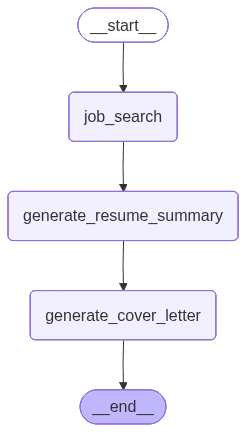

In [12]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
input_state = {
        "user_query": "data scientist"
}
result=app.invoke(input_state)

In [14]:
result['job_search']

[{'company': 'stripe',
  'title': 'Data Scientist',
  'location': 'Seattle, WA',
  'url': 'https://stripe.com/jobs/search?gh_jid=7809414',
  'description': '&lt;h2&gt;&lt;strong&gt;Who we are &lt;/strong&gt;&lt;/h2&gt;\n&lt;h3&gt;&lt;strong&gt;About Stripe&lt;/strong&gt;&lt;/h3&gt;\n&lt;p&gt;&lt;span style=&quot;font-weight: 400;&quot;&gt;Stripe is a financial infrastructure platform for businesses. Millions of companies - from the world’s largest enterprises to the most ambitious startups - use Stripe to accept payments, grow their revenue, and accelerate new business opportunities. Our mission is to increase the GDP of the internet, and we have a staggering amount of work ahead. That means you have an unprecedented opportunity to put the global economy within everyone&#39;s reach while doing the most important work of your career.&lt;/span&gt;&lt;/p&gt;\n&lt;h2&gt;&lt;strong&gt;What you’ll do&lt;/strong&gt;&lt;/h2&gt;\n&lt;h3&gt;&lt;strong&gt;Responsibilities&lt;/strong&gt;&lt;/h3&gt

In [15]:
from pprint import pprint
pprint(result['resume_summary'])

('# Resume Summary\n'
 '\n'
 "**Data Scientist** with a Master's degree in Computer Science (or related "
 'quantitative field) and 3+ years of experience delivering end-to-end data '
 'science solutions in fast-paced, high-impact environments. Proven track '
 'record partnering with cross-functional stakeholders including Sales, '
 'Product, and Data Science teams to translate complex business questions into '
 'actionable, data-driven insights and scalable solutions.\n'
 '\n'
 '## Core Qualifications\n'
 '\n'
 '- **Advanced Analytics & Modeling**: 2+ years applying statistical methods, '
 'time series forecasting, and machine learning models to large-scale datasets '
 'to predict user and product performance.\n'
 '\n'
 '- **End-to-End ML Productionization**: 2+ years designing, implementing, and '
 'launching production-grade machine learning models and software solutions, '
 'with hands-on experience in software architecture design and analysis.\n'
 '\n'
 '- **SQL & Data Engineering

In [16]:
pprint(result['cover_letter'])

('# Cover Letter for Data Scientist Position at Stripe\n'
 '\n'
 '---\n'
 '\n'
 '**[Your Name]**\n'
 '[Your Address]\n'
 '[City, State, ZIP Code]\n'
 '[Your Email] | [Your Phone Number]\n'
 '[LinkedIn Profile URL]\n'
 '\n'
 '[Date]\n'
 '\n'
 '**Hiring Manager**\n'
 'Stripe, Inc.\n'
 '[Company Address]\n'
 'San Francisco, CA [ZIP Code]\n'
 '\n'
 '---\n'
 '\n'
 'Dear Hiring Manager,\n'
 '\n'
 "When I read that Stripe's mission is to increase the GDP of the internet, it "
 "resonated immediately with the kind of impact I've spent my career pursuing: "
 'turning complex data into decisions that move real business metrics at '
 "scale. With a Master's degree in Computer Science and over three years of "
 'experience delivering end-to-end data science solutions in high-stakes '
 'environments, I am excited to apply for the Data Scientist position and '
 'contribute to the financial infrastructure that powers millions of '
 'businesses worldwide.\n'
 '\n'
 'Throughout my career, I have built 

In [37]:
class graphstate(TypedDict):
    resume_path:str
    resume_text:str
    resume_skills:list[str]
    resume_experience:list[str]
    

In [38]:
from langchain_community.document_loaders import PyPDFLoader
def load_pdf_agent(state:graphstate)->graphstate:
    resume_path=state['resume_path']
    loader = PyPDFLoader(resume_path)
    docs = loader.load()

    text = "\n".join(doc.page_content for doc in docs)
    return {**state,"resume_text":text}

In [39]:
def skill_extraction_agent(state:graphstate)->graphstate:

    prompt = f"""
    Extract the user skills  from this resume.

    Resume:
    {state['resume_text']}

    Return only a Python list.

    Example:
    ["Python","SQL","TensorFlow"]
    """

    response = llm.invoke(prompt)

    return {
        **state,
        "resume_skills": response.content
    }

In [40]:
def experience_extraction_agent(state:graphstate)->graphstate:

    prompt = f"""
    You are an expert experience extractor agent.

    Resume:
        {state['resume_text']}


    Generate 3-5 professional work experience bullet points that demonstrate how these skills were applied in real projects or job responsibilities.

    Requirements:
    - Use strong action verbs.
    - Quantify achievements whenever possible.
    - Keep each bullet concise (1-2 lines).
    - Write in ATS-friendly resume format.

    Return only the bullet points.
    """
    response=llm.invoke(prompt)


    return {
        **state,
        "resume_experience": response.content
    }

In [41]:
from langchain_core.documents import Document
from langchain_qdrant import QdrantVectorStore

In [42]:
def qdrant_store_agent(state:graphstate)->graphstate:

    docs = [

        Document(
            page_content=state["resume_skills"],
            metadata={
                "section":"skills"
            }
        ),

        Document(
            page_content=state["resume_experience"],
            metadata={
                "section":"experience"
            }
        )

    ]

    QdrantVectorStore.from_documents(
        docs,
        embedding_model,
        path="./qdrant_db",
        collection_name="resume"
    )

    return state

In [43]:
workflow=StateGraph(graphstate)
workflow

In [44]:

workflow.add_node('load_pdf_agent',load_pdf_agent)
workflow.add_node('qdrant_store_agent',qdrant_store_agent)
workflow.add_node('skill_extraction_agent',skill_extraction_agent)
workflow.add_node('experience_extraction_agent',experience_extraction_agent)
workflow.set_entry_point('load_pdf_agent')
workflow.add_edge('load_pdf_agent','skill_extraction_agent')
workflow.add_edge('skill_extraction_agent','experience_extraction_agent')
workflow.add_edge('experience_extraction_agent','qdrant_store_agent')
workflow.set_finish_point('qdrant_store_agent')

In [45]:
app=workflow.compile()

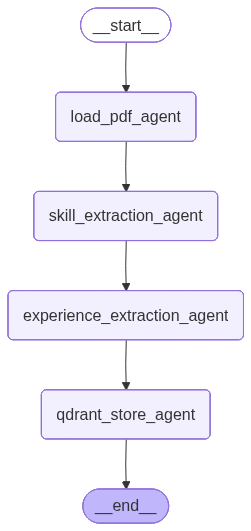

In [46]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [47]:
input_state = {
        "resume_path": "data_scientist_resume_sample.pdf"
}
result=app.invoke(input_state)

In [48]:
pprint(result['resume_text'])

('John Doe\n'
 'Data Scientist\n'
 'Email: john.doe@email.com | Phone: +1-555-123-4567 | LinkedIn: '
 'linkedin.com/in/johndoe |\n'
 'GitHub: github.com/johndoe\n'
 'Professional Summary\n'
 'Results-driven Data Scientist with 3+ years of experience in machine '
 'learning, data analysis, and\n'
 'predictive modeling. Proficient in Python, SQL, TensorFlow, scikit-learn, '
 'and data visualization\n'
 'tools.\n'
 'Technical Skills\n'
 'Python, SQL, Pandas, NumPy, Scikit-learn, TensorFlow, PyTorch, Matplotlib, '
 'Seaborn, Power BI,\n'
 'Tableau, Git, Docker\n'
 'Experience\n'
 'Data Scientist, ABC Analytics (2023-Present) - Developed customer churn '
 'prediction models\n'
 'improving retention by 15%. - Built ETL pipelines and automated reporting '
 'dashboards. - Applied\n'
 'NLP techniques for sentiment analysis.\n'
 'Projects\n'
 '\x7f House Price Prediction using XGBoost \x7f Customer Segmentation with '
 'K-Means Clustering \x7f\n'
 'NLP-based Sentiment Analysis System\n'
 'Educat

In [49]:
pprint(result['resume_skills'])

('["Python", "SQL", "Pandas", "NumPy", "Scikit-learn", "TensorFlow", '
 '"PyTorch", "Matplotlib", "Seaborn", "Power BI", "Tableau", "Git", "Docker"]')


In [50]:
pprint(result['resume_experience'])

('- Developed and deployed customer churn prediction models using Python and '
 'scikit-learn, improving customer retention rates by 15% and reducing revenue '
 'loss.\n'
 '- Engineered scalable ETL pipelines and automated reporting dashboards with '
 'SQL and Python, reducing manual data processing time by 40%.\n'
 '- Implemented NLP-based sentiment analysis system using TensorFlow to '
 'process and analyze 10,000+ customer reviews, providing actionable business '
 'insights.\n'
 '- Built predictive house price models utilizing XGBoost and machine learning '
 'algorithms, achieving 92% prediction accuracy on validation datasets.\n'
 '- Executed customer segmentation analysis using K-Means clustering to '
 'identify 5 distinct customer personas, driving targeted marketing strategy '
 'improvements.')
